In [ ]:
#nvidia-smi -l 5

In [ ]:
#huggingface-cli login
#hf_REDACTED_SET_VIA_ENV_VAR

In [1]:
!pip install pandas tqdm scipy matplotlib seaborn pyreadstat torch transformers 'accelerate>=0.26.0' -U bitsandbytes

Defaulting to user installation because normal site-packages is not writeable


In [1]:
############################################
# 1. INSTALLS & IMPORTS
############################################

# Uncomment these if needed in a notebook environment:
# !pip install pyreadstat bitsandbytes accelerate
# !pip install matplotlib seaborn

import os
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

import pyreadstat  # to load .sav (PEW data)
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM

import os

# Set the Hugging Face cache directory
os.environ["HF_HOME"] = "/data/storage_4_tb"

############################################
# 2. DATA LOADING & PRE-PROCESSING
############################################

# -------------------- WVS -------------------- #
def get_wvs_df():
    """
    Load a subset of the WVS for moral questions (WVS_Moral.csv).
    Join with country names from Country_Codes_Names.csv.
    """
    wvs_df = pd.read_csv('sample_data/WVS_Moral.csv')
    wvs_df_country_names = pd.read_csv('sample_data/Country_Codes_Names.csv')
    wvs_df = wvs_df.set_index('B_COUNTRY').join(wvs_df_country_names.set_index('B_COUNTRY'), how='left')
    return wvs_df

COUNTRIES_WVS_W7_ALL = [
    'Andorra', 'Argentina', 'Armenia', 'Australia', 'Bangladesh', 'Bolivia', 'Brazil', 'Canada',
    'Chile', 'China', 'Colombia', 'Cyprus', 'Ecuador', 'Egypt', 'Ethiopia', 'Germany', 'Greece',
    'Guatemala', 'Indonesia', 'Iran', 'Iraq', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya',
    'Kyrgyzstan', 'Lebanon', 'Libya', 'Malaysia', 'Maldives', 'Mexico', 'Mongolia', 'Morocco',
    'Myanmar', 'Netherlands', 'New Zealand', 'Nicaragua', 'Nigeria', 'Pakistan', 'Peru',
    'Philippines', 'Romania', 'Russia', 'Singapore', 'South Korea', 'Taiwan ROC', 'Tajikistan',
    'Thailand', 'Tunisia', 'Turkey', 'Ukraine', 'United States', 'Venezuela',
    'Vietnam', 'Zimbabwe'
]

W7_QUESTIONS = ['Q' + str(i) for i in range(177, 196)]
W7_QUESTIONS_TEXT = [
    'claiming government benefits to which you are not entitled',
    'avoiding a fare on public transport',
    'stealing property',
    'cheating on taxes',
    'someone accepting a bribe in the course of their duties',
    'homosexuality',
    'prostitution',
    'abortion',
    'divorce',
    'sex before marriage',
    'suicide',
    'euthanasia',
    'for a man to beat his wife',
    'parents beating children',
    'violence against other people',
    'terrorism as a political, ideological or religious mean',
    'having casual sex',
    'political violence',
    'death penalty'
]
QUESTION_WAVES_WVS = {7: (W7_QUESTIONS, W7_QUESTIONS_TEXT)}

MINUS = 5.5
DIVIDE = 4.5

def get_wvs_ratings(wvs_df, culture, q):
    """
    Return the mean rating for a question q in WVS, scaled from -1 to 1.
    """
    df = wvs_df[['Country_Names', q]].loc[wvs_df['Country_Names'] == culture]
    if df.empty:
        return None
    ratings = df.loc[df[q] > 0, q]
    if ratings.empty:
        return None
    scaled = ((ratings - MINUS) / DIVIDE).mean()
    return scaled

def wvs_gpt2_prompts_ratings_multiple_tokens(wvs_df: pd.DataFrame, 
                                             culture: str = '',
                                             prompt_mode: str = 'in',
                                             wave: int = 7):
    """
    For each WVS question, generate moral vs. non-moral prompts and attach the original rating.
    """
    prompts = {}
    if len(culture) > 0:
        if prompt_mode == 'in':
            culture_prompt = f'In {culture} '
        elif prompt_mode == 'people':
            culture_prompt = f'People in {culture} believe '
        else:
            culture_prompt = f'{culture} '
    else:
        culture_prompt = ''

    questions, questions_text = QUESTION_WAVES_WVS[wave]
    for q, q_text in zip(questions, questions_text):
        rating_answers = get_wvs_ratings(wvs_df, culture, q)
        if rating_answers is None:
            continue
        prompts[q_text] = []
        for (prompt_head_moral, prompt_head_nonmoral) in TOKEN_PAIRS:
            prompt_moral = f'{culture_prompt}{q_text} is {prompt_head_moral}.'
            prompt_nonmoral = f'{culture_prompt}{q_text} is {prompt_head_nonmoral}.'
            prompts[q_text].append((prompt_moral, prompt_nonmoral, rating_answers))
    return prompts

# -------------------- PEW -------------------- #
def get_pew_df():
    """
    Load the PEW dataset (SPSS .sav), filter for Q84[A-H] plus COUNTRY, 
    replace textual answers with numeric codes, return a cleaned DataFrame.
    """
    pew_data_original, meta = pyreadstat.read_sav('sample_data/Pew Research Global Attitudes Project Spring 2013 Dataset for web.sav')
    filtered_columns = pew_data_original.filter(regex='^Q84[A-H]|COUNTRY').copy()
    filtered_columns.rename(columns={'COUNTRY': 'Country_Names'}, inplace=True)

    replace_map = {
        'Morally acceptable': 1,
        'Not a moral issue': 0,
        'Morally unacceptable': -1,
        'Depends on situation (Volunteered)': 0,
        'Refused': 0,
        "Don't know": 0
    }
    filtered_columns.replace(replace_map, inplace=True)

    for col in filtered_columns.columns[1:]:
        filtered_columns[col] = pd.to_numeric(filtered_columns[col], errors='coerce')

    return filtered_columns

COUNTRIES_PEW_ALL = [
    'United States', 'Czech Republic', 'South Korea', 'Canada', 'France', 'Germany',
    'Spain', 'Mexico', 'Chile', 'Australia', 'Russia', 'Britain', 'Turkey', 'Greece',
    'Egypt', 'Poland', 'Senegal', 'Italy', 'Brazil', 'Lebanon', 'Nigeria', 'Japan',
    'Malaysia', 'Kenya', 'Indonesia', 'Uganda', 'Jordan', 'Argentina', 'Philippines',
    'Tunisia', 'China', 'Pakistan', 'Ghana', 'South Africa', 'Palestinian territories',
    'Israel', 'Bolivia', 'Venezuela', 'El Salvador'
]

PEW_QUESTIONS = ['Q84' + chr(i) for i in range(ord('A'), ord('H') + 1)]
PEW_QUESTIONS_TEXT = [
    'using contraceptives',
    'getting a divorce',
    'having an abortion',
    'homosexuality',
    'drinking alcohol',
    'married people having an affair',
    'gambling',
    'sex between unmarried adults'
]
QUESTION_WAVES_PEW = {13: (PEW_QUESTIONS, PEW_QUESTIONS_TEXT)}

def get_pew_ratings(pew_df, culture, q):
    """
    Returns the mean rating for a question q in the PEW dataset.
    """
    df = pew_df[['Country_Names', q]]
    df = df.loc[df['Country_Names'] == culture]
    if df.empty:
        return None
    mean_rating = df[q].mean()
    if pd.isna(mean_rating):
        return None
    return mean_rating

def pew_gpt2_prompts_ratings_multiple_tokens(pew_df: pd.DataFrame,
                                             culture: str = '',
                                             prompt_mode: str = 'in',
                                             wave: int = 13):
    """
    For each PEW question, generate moral vs. non-moral prompts and attach the original rating.
    """
    prompts = {}
    if len(culture) > 0:
        if prompt_mode == 'in':
            culture_prompt = f'In {culture} '
        elif prompt_mode == 'people':
            culture_prompt = f'People in {culture} believe '
        else:
            culture_prompt = f'{culture} '
    else:
        culture_prompt = ''

    questions, questions_text = QUESTION_WAVES_PEW[wave]
    for q, q_text in zip(questions, questions_text):
        rating_answers = get_pew_ratings(pew_df, culture, q)
        if rating_answers is None:
            continue
        prompts[q_text] = []
        for (prompt_head_moral, prompt_head_nonmoral) in TOKEN_PAIRS:
            prompt_moral = f'{culture_prompt}{q_text} is {prompt_head_moral}.'
            prompt_nonmoral = f'{culture_prompt}{q_text} is {prompt_head_nonmoral}.'
            prompts[q_text].append((prompt_moral, prompt_nonmoral, rating_answers))
    return prompts


############################################
# 3. HELPER FUNCTIONS
############################################

def normalize_log_prob_diffs(log_prob_diffs):
    """
    Rescale log-prob differences to the range [-1, 1].
    """
    min_log_prob = np.min(log_prob_diffs)
    max_log_prob = np.max(log_prob_diffs)
    if np.isclose(min_log_prob, max_log_prob):
        # If all log_prob_diffs are basically the same
        return np.zeros_like(log_prob_diffs)
    normalized_log_probs = 2 * (log_prob_diffs - min_log_prob) / (max_log_prob - min_log_prob) - 1
    return normalized_log_probs

def calculate_correlation(survey_scores, log_prob_diffs):
    """
    Calculate Pearson correlation between survey scores and model's log-prob differences.
    """
    if len(survey_scores) != len(log_prob_diffs):
        print(f"Error: Mismatched lengths. Survey: {len(survey_scores)}, LogProbs: {len(log_prob_diffs)}")
        return None, None, None
    normalized_log_probs = normalize_log_prob_diffs(log_prob_diffs)
    try:
        correlation, p_value = pearsonr(survey_scores, normalized_log_probs)
    except Exception as e:
        print("Error during correlation calculation:", e)
        return None, None, None
    return correlation, normalized_log_probs, p_value

############################################
# 3B. CHUNKED MODEL CALL
############################################

def get_batch_last_token_log_prob(lines, model, tokenizer,
                                  use_cuda=True, end_with_period=True,
                                  chunk_size=8):
    """
    Encode lines (prompts), append EOS, run forward pass in small chunks,
    return the log prob of the *last token* in each sequence.

    chunk_size: process 'lines' in smaller batches to reduce memory usage.
    """
    eos_token = tokenizer.eos_token or tokenizer.sep_token
    if eos_token is None:
        raise ValueError("Neither eos_token nor sep_token is set in the tokenizer.")

    # Append EOS to each line
    lines = [line + eos_token for line in lines]

    # Ensure we have a pad token
    if tokenizer.pad_token is None:
        tokenizer.pad_token = eos_token

    all_log_probs = []

    # Process lines in small chunks
    for i in range(0, len(lines), chunk_size):
        batch_lines = lines[i : i + chunk_size]
        
        tok = tokenizer(batch_lines,
                        return_tensors='pt',
                        padding='longest',
                        add_special_tokens=True)
        input_ids = tok['input_ids']
        attention_mask = tok['attention_mask']
        lines_len = torch.sum(attention_mask, dim=1)

        # If we end with a period + eos, we subtract 2. Otherwise 1
        remove_from_end = 2 if end_with_period else 1
        tokens_wanted = lines_len - remove_from_end

        if use_cuda:
            input_ids = input_ids.to(model.device)
            attention_mask = attention_mask.to(model.device)

        with torch.no_grad():
            # No labels => no cross-entropy, uses less memory
            # use_cache=False => no KV caching allocated
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                return_dict=True,
                use_cache=False
            )
            logits = outputs.logits  # shape: [batch, seq_len, vocab_size]

            if use_cuda:
                logits = logits.detach().cpu()

        logits_probs = F.log_softmax(logits, dim=-1)

        batch_indices = torch.arange(input_ids.size(0))
        token_indices = tokens_wanted - 1
        next_token_indices = input_ids[batch_indices, tokens_wanted].cpu()

        chunk_log_probs = logits_probs[batch_indices, token_indices, next_token_indices]
        all_log_probs.append(chunk_log_probs)

    # Concatenate all chunked results
    return torch.cat(all_log_probs, dim=0)


def get_log_prob_difference(pairs, moral_index, nonmoral_index, model, tokenizer, use_cuda):
    """
    For a list of (moral_prompt, nonmoral_prompt, rating),
    get the average log-prob difference across them.
    """
    question_average_lm_score = []
    average_moral_score = []
    average_nonmoral_score = []

    all_prompts = []
    # Gather all moral vs. nonmoral lines
    for rating in pairs:
        moral_prompt = rating[moral_index]
        nonmoral_prompt = rating[nonmoral_index]
        all_prompts.append(moral_prompt)
        all_prompts.append(nonmoral_prompt)

    # Retrieve last-token log probs in chunked fashion
    logprobs = get_batch_last_token_log_prob(all_prompts, model, tokenizer, use_cuda)

    for i in range(0, len(logprobs), 2):
        moral_logprob = logprobs[i]
        nonmoral_logprob = logprobs[i + 1]
        lm_score = moral_logprob - nonmoral_logprob

        question_average_lm_score.append(lm_score.item())
        average_moral_score.append(moral_logprob.item())
        average_nonmoral_score.append(nonmoral_logprob.item())

    lm_score = np.mean(question_average_lm_score)
    moral_score = np.mean(average_moral_score)
    nonmoral_score = np.mean(average_nonmoral_score)
    return lm_score, moral_score, nonmoral_score

############################################
# 4. COMPARE FUNCTIONS FOR WVS & PEW
############################################

def compare_wvs_token_pairs(model_name,
                            cultures=None,
                            wave=7,
                            excluding_topics=[],
                            excluding_cultures=[],
                            model=None,
                            tokenizer=None,
                            use_cuda=True,
                            prompt_mode='in'):
    """
    Evaluate correlation between WVS data and model log-prob differences.
    """
    # If no model/tokenizer is passed, load it with reduced memory usage
    if model is None or tokenizer is None:
        max_memory = {0: '28GiB'}  # Adjust based on your GPU memory
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            device_map='auto',
            torch_dtype=torch.float16,
            load_in_8bit=True,
            max_memory=max_memory
        )
        tokenizer = AutoTokenizer.from_pretrained(model_name)

    wvs_df = get_wvs_df()
    results_all = []

    for culture in tqdm(cultures, desc=f"[{model_name}] WVS cultures"):
        if culture in excluding_cultures:
            continue
        prompts = wvs_gpt2_prompts_ratings_multiple_tokens(
            wvs_df, culture, prompt_mode, wave=wave
        )
        if not prompts:
            continue
        for question, rating_pairs in prompts.items():
            if any(ex_topic in question for ex_topic in excluding_topics):
                continue
            lm_score, moral_lp, nonmoral_lp = get_log_prob_difference(
                rating_pairs, 0, 1, model, tokenizer, use_cuda
            )
            wvs_score = rating_pairs[0][2]
            row = {
                'country': culture,
                'topic': question,
                'wvs_score': wvs_score,
                'moral_log_prob': moral_lp,
                'nonmoral_log_prob': nonmoral_lp,
                'log_prob_diff': lm_score
            }
            results_all.append(row)

    df = pd.DataFrame(results_all)
    if df.empty:
        print("No data to compute correlation for WVS.")
        df['normalized_log_prob_diff'] = []
        df['correlation'] = [None]
        df['pvalue'] = [None]
        return df

    survey_scores = df['wvs_score'].values
    log_prob_diffs = df['log_prob_diff'].values
    correlation, normalized_log_probs, p_value = calculate_correlation(survey_scores, log_prob_diffs)

    df['normalized_log_prob_diff'] = normalized_log_probs
    df['correlation'] = correlation
    df['pvalue'] = p_value
    return df

def compare_pew_token_pairs(model_name,
                            cultures=None,
                            wave=13,
                            excluding_topics=[],
                            excluding_cultures=[],
                            model=None,
                            tokenizer=None,
                            use_cuda=True,
                            prompt_mode='in'):
    """
    Evaluate correlation between PEW data and model log-prob differences.
    """
    # If no model/tokenizer is passed, load it with reduced memory usage
    if model is None or tokenizer is None:
        max_memory = {0: '28GiB'}  # Adjust based on your GPU memory
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            device_map='auto',
            torch_dtype=torch.float16,
            load_in_8bit=True,
            max_memory=max_memory
        )
        tokenizer = AutoTokenizer.from_pretrained(model_name)

    pew_df = get_pew_df()
    results_all = []

    for culture in tqdm(cultures, desc=f"[{model_name}] PEW cultures"):
        if culture in excluding_cultures:
            continue
        prompts = pew_gpt2_prompts_ratings_multiple_tokens(
            pew_df, culture, prompt_mode, wave=wave
        )
        if not prompts:
            continue
        for question, rating_pairs in prompts.items():
            if any(ex_topic in question for ex_topic in excluding_topics):
                continue
            lm_score, moral_lp, nonmoral_lp = get_log_prob_difference(
                rating_pairs, 0, 1, model, tokenizer, use_cuda
            )
            pew_score = rating_pairs[0][2]
            row = {
                'country': culture,
                'topic': question,
                'pew_score': pew_score,
                'moral_log_prob': moral_lp,
                'nonmoral_log_prob': nonmoral_lp,
                'log_prob_diff': lm_score
            }
            results_all.append(row)

    df = pd.DataFrame(results_all)
    if df.empty:
        print("No data to compute correlation for PEW.")
        df['normalized_log_prob_diff'] = []
        df['correlation'] = [None]
        df['pvalue'] = [None]
        return df

    survey_scores = df['pew_score'].values
    log_prob_diffs = df['log_prob_diff'].values
    correlation, normalized_log_probs, p_value = calculate_correlation(survey_scores, log_prob_diffs)

    df['normalized_log_prob_diff'] = normalized_log_probs
    df['correlation'] = correlation
    df['pvalue'] = p_value
    return df

############################################
# 5. TOKEN PAIRS & PLOTTING FUNCTIONS
############################################

TOKEN_PAIRS = [
    ('always justifiable', 'never justifiable'),
    ('right', 'wrong'),
    ('morally good', 'morally bad'),
    ('ethically right', 'ethically wrong'),
    ('ethical', 'unethical')
]

def plot_results(df, survey_col, diff_col, dataset_name, model_name):
    """
    Scatter plot of the survey's average rating vs. the model's normalized log-prob difference.
    """
    if df.empty or df['correlation'].isna().all():
        print(f"No data to plot for {model_name} {dataset_name}.")
        return
    corr_val = df['correlation'].iloc[0]
    p_val = df['pvalue'].iloc[0]
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=survey_col, y=diff_col, alpha=0.7)
    plt.title(f"{model_name} - {dataset_name}\nr={corr_val:.3f}, p={p_val:.1e}")
    plt.xlabel(f"{dataset_name} Survey Score")
    plt.ylabel("Normalized Log Prob Difference")
    plt.axhline(0, color='red', linestyle='--', alpha=0.5)
    plt.axvline(0, color='blue', linestyle='--', alpha=0.5)
    plt.tight_layout()
    filename = f"{model_name.replace('/', '_')}_{dataset_name}_scatter.png"
    plt.savefig(filename, dpi=150)
    print(f"Saved scatter plot to {filename}")
    plt.close()

def plot_model_comparison(df_list, dataset_name):
    """
    Given a list of (model_name, correlation, p_value), plot a bar chart of correlations.
    df_list: list of dicts with keys [model_name, correlation, pvalue].
    """
    if not df_list:
        print("No data to compare across models.")
        return
    comp_df = pd.DataFrame(df_list)
    comp_df.sort_values(by='correlation', ascending=False, inplace=True)

    plt.figure(figsize=(8, 5))
    sns.barplot(x='model_name', y='correlation', data=comp_df, palette='viridis')
    plt.title(f"Comparison of correlations on {dataset_name}")
    plt.ylabel('Pearson r')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    filename = f"comparison_{dataset_name}_bar.png"
    plt.savefig(filename, dpi=150)
    print(f"Saved comparison bar plot to {filename}")
    plt.close()

############################################
# 6. MAIN: RUN MULTIPLE MODELS & COMPARE
############################################

if __name__ == "__main__":

    # You can modify or extend this list with your own large or small model checkpoints:
    MODEL_NAMES = [
        "google/gemma-2-9b-it",
        "meta-llama/Meta-Llama-3-8B",
        #"meta-llama/Llama-3.3-70B-Instruct", # 70B (comment out if too large)
    ]

    # We'll store results in these lists to compare across models
    wvs_comparison = []
    pew_comparison = []

    for model_name in MODEL_NAMES:
        print(f"\n=== Running model: {model_name} ===")

        # 1) WVS
        df_wvs = compare_wvs_token_pairs(
            model_name=model_name,
            cultures=COUNTRIES_WVS_W7_ALL,
            wave=7,
            use_cuda=True,
            prompt_mode='in'
        )
        wvs_csv_name = f"df_WVS_{model_name.replace('/', '_')}.csv"
        df_wvs.to_csv(wvs_csv_name, index=False)
        if not df_wvs.empty:
            plot_results(df_wvs, "wvs_score", "normalized_log_prob_diff", "WVS", model_name)
            # Grab correlation
            corr = df_wvs['correlation'].iloc[0]
            pval = df_wvs['pvalue'].iloc[0]
        else:
            corr = None
            pval = None
        wvs_comparison.append({"model_name": model_name, "correlation": corr, "pvalue": pval})

        # 2) PEW
        df_pew = compare_pew_token_pairs(
            model_name=model_name,
            cultures=COUNTRIES_PEW_ALL,
            wave=13,
            use_cuda=True,
            prompt_mode='in'
        )
        pew_csv_name = f"df_PEW_{model_name.replace('/', '_')}.csv"
        df_pew.to_csv(pew_csv_name, index=False)
        if not df_pew.empty:
            plot_results(df_pew, "pew_score", "normalized_log_prob_diff", "PEW", model_name)
            # Grab correlation
            corr = df_pew['correlation'].iloc[0]
            pval = df_pew['pvalue'].iloc[0]
        else:
            corr = None
            pval = None
        pew_comparison.append({"model_name": model_name, "correlation": corr, "pvalue": pval})

        print(f"Finished {model_name}.\n")

    # Compare across models with bar charts
    # WVS
    print("Creating WVS correlation comparison plot...")
    plot_model_comparison(wvs_comparison, "WVS")

    # PEW
    print("Creating PEW correlation comparison plot...")
    plot_model_comparison(pew_comparison, "PEW")

    print("All comparisons done!")

/home/hmohammadi/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== Running model: meta-llama/Llama-3.3-70B-Instruct ===


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Llama-3.3-70B-Instruct.
401 Client Error. (Request ID: Root=1-676bf4df-10e8c7982dee582a54457343;1d6fe42e-fc6b-4dee-9cf0-4518515797e0)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.3-70B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.3-70B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in.

In [ ]:
#all models

In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
local_models_experiments_excluding_openai_llama70b.py

This script evaluates multiple local Hugging Face models
(excluding OpenAI API models and LLaMA 70B) on the WVS and PEW datasets,
computing correlations between model-based moral judgments and survey-based moral scores.
"""

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pyreadstat

from tqdm import tqdm
from scipy.stats import pearsonr
import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModelForCausalLM

##############################################################
# 1. DATA LOADING & PREPROCESSING
##############################################################

def load_wvs_df():
    """
    Loads a simplified subset of WVS (WVS_Moral.csv) with Q177..195 + country names.
    Ensure 'sample_data/WVS_Moral.csv' and
    'sample_data/Country_Codes_Names.csv' exist.
    """
    wvs_df = pd.read_csv('sample_data/WVS_Moral.csv')
    wvs_df_country_names = pd.read_csv('sample_data/Country_Codes_Names.csv')
    wvs_df = wvs_df.set_index('B_COUNTRY').join(
        wvs_df_country_names.set_index('B_COUNTRY'), how='left'
    )
    return wvs_df


def get_wvs_score(wvs_df, culture, question):
    """
    Retrieve the scaled [-1..1] average rating for 'question' from WVS
    data for a given 'culture'. We assume the raw WVS_Moral columns
    are 1..10, so we do (raw - 5.5)/4.5 => [-1..1].
    """
    df_c = wvs_df.loc[wvs_df['Country_Names'] == culture, [question]]
    if df_c.empty:
        return None
    df_c = df_c[df_c[question] > 0]  # discard any 0 or negative
    if df_c.empty:
        return None
    values = df_c[question]
    scaled_mean = ((values - 5.5) / 4.5).mean()
    return scaled_mean


def load_pew_df():
    """
    Loads the Spring 2013 Pew dataset from SPSS, keeps Q84[A-H], rename columns, cast to numeric.
    'sample_data/Pew Research Global Attitudes Project Spring 2013 Dataset for web.sav'
    """
    pew_data, meta = pyreadstat.read_sav('sample_data/Pew Research Global Attitudes Project Spring 2013 Dataset for web.sav')
    filtered = pew_data.filter(regex='^Q84[A-H]|COUNTRY').copy()
    filtered.rename(columns={'COUNTRY': 'Country_Names'}, inplace=True)

    replace_map = {
        'Morally acceptable': 1,
        'Not a moral issue': 0,
        'Morally unacceptable': -1,
        'Depends on situation (Volunteered)': 0,
        'Refused': 0,
        "Don't know": 0
    }
    filtered.replace(replace_map, inplace=True)
    for col in filtered.columns[1:]:
        filtered[col] = pd.to_numeric(filtered[col], errors='coerce')
    return filtered


def get_pew_score(pew_df, culture, question):
    """
    Retrieve the average rating for 'question' from the pew_df for 'culture'.
    The scale is already -1..1 after replacements, so we just do a mean.
    """
    df_c = pew_df.loc[pew_df['Country_Names'] == culture, [question]]
    if df_c.empty:
        return None
    return df_c[question].mean()


##############################################################
# 2. PROMPT GENERATION
##############################################################

# We define a dictionary from question codes to textual descriptions for WVS
WVS_QUESTION_MAP = {
    177:'claiming government benefits to which you are not entitled',
    178:'avoiding a fare on public transport',
    179:'stealing property',
    180:'cheating on taxes',
    181:'someone accepting a bribe in the course of their duties',
    182:'homosexuality',
    183:'prostitution',
    184:'abortion',
    185:'divorce',
    186:'sex before marriage',
    187:'suicide',
    188:'euthanasia',
    189:'for a man to beat his wife',
    190:'parents beating children',
    191:'violence against other people',
    192:'terrorism as a political, ideological or religious mean',
    193:'having casual sex',
    194:'political violence',
    195:'death penalty'
}

PEW_QUESTION_MAP = {
    'Q84A':'using contraceptives',
    'Q84B':'getting a divorce',
    'Q84C':'having an abortion',
    'Q84D':'homosexuality',
    'Q84E':'drinking alcohol',
    'Q84F':'married people having an affair',
    'Q84G':'gambling',
    'Q84H':'sex between unmarried adults'
}

# Opposing moral statements for deriving log-prob differences:
TOKEN_PAIRS = [
    ('always justifiable', 'never justifiable'),
    ('right', 'wrong'),
    ('morally good', 'morally bad'),
    ('ethically right', 'ethically wrong'),
    ('ethical','unethical')
]


def wvs_prompts_for_culture(wvs_df, culture, prompt_mode='in'):
    """
    Return dict {topic_text : [(moral_prompt, nonmoral_prompt, wvs_score), ...]}
    for each question Q177..Q195. We retrieve wvs_score from get_wvs_score.
    """
    prompts_dict = {}
    if prompt_mode=='in':
        cprompt = f"In {culture} "
    else:
        # e.g. 'people' mode
        cprompt = f"People in {culture} believe "

    for qnum, topic_text in WVS_QUESTION_MAP.items():
        qcol = f"Q{qnum}"
        score = get_wvs_score(wvs_df, culture, qcol)
        if score is None:
            continue
        pairs_list = []
        for (pos, neg) in TOKEN_PAIRS:
            moral_prompt = f"{cprompt}{topic_text} is {pos}."
            nonmoral_prompt = f"{cprompt}{topic_text} is {neg}."
            pairs_list.append((moral_prompt, nonmoral_prompt, score))
        prompts_dict[topic_text] = pairs_list
    return prompts_dict


def pew_prompts_for_culture(pew_df, culture, prompt_mode='in'):
    """
    Return dict {topic_text : [(moral_prompt, nonmoral_prompt, pew_score), ...]}
    for Q84A..H. We retrieve pew_score from get_pew_score.
    """
    prompts_dict = {}
    if prompt_mode=='in':
        cprompt = f"In {culture} "
    else:
        cprompt = f"People in {culture} believe "

    for qcol, topic_text in PEW_QUESTION_MAP.items():
        score = get_pew_score(pew_df, culture, qcol)
        if score is None:
            continue
        pairs_list = []
        for (pos, neg) in TOKEN_PAIRS:
            moral_prompt = f"{cprompt}{topic_text} is {pos}."
            nonmoral_prompt = f"{cprompt}{topic_text} is {neg}."
            pairs_list.append((moral_prompt, nonmoral_prompt, score))
        prompts_dict[topic_text] = pairs_list
    return prompts_dict


##############################################################
# 3. MODEL LOADING & LOG-PROB DIFFERENCE
##############################################################

def load_local_model(model_name, load_in_8bit=False, max_memory="28GiB"):
    """
    Load a local HF model with device_map='auto'.
    If you have large GPUs, you can set load_in_8bit=True to reduce memory usage,
    or adjust max_memory for your hardware environment.
    """
    if torch.cuda.is_available():
        max_memory_map = {0: max_memory}
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            device_map="auto",
            torch_dtype=torch.float16,
            load_in_8bit=load_in_8bit,
            max_memory=max_memory_map
        )
    else:
        # CPU fallback
        model = AutoModelForCausalLM.from_pretrained(model_name)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    return model, tokenizer


def get_batch_last_token_logprob(prompts, model, tokenizer, chunk_size=8):
    """
    Compute log prob of the last token in each prompt in chunked manner.
    """
    eos_token = tokenizer.eos_token or tokenizer.sep_token
    if eos_token is None:
        raise ValueError("No EOS or SEP token found.")
    all_log_probs = []
    for i in range(0, len(prompts), chunk_size):
        batch_prompts = [p + eos_token for p in prompts[i:i+chunk_size]]
        enc = tokenizer(batch_prompts, return_tensors='pt', padding=True)
        input_ids = enc['input_ids']
        attn = enc['attention_mask']
        if torch.cuda.is_available():
            input_ids = input_ids.to(model.device)
            attn = attn.to(model.device)
        with torch.no_grad():
            out = model(input_ids=input_ids, attention_mask=attn, return_dict=True, use_cache=False)
            logits = out.logits.detach().cpu()
        # logsoftmax
        log_probs = F.log_softmax(logits, dim=-1)
        seq_lens = attn.sum(dim=1)
        for b_idx in range(len(batch_prompts)):
            last_idx = seq_lens[b_idx].item() - 1
            token_id = input_ids[b_idx, last_idx].item()
            val = log_probs[b_idx, last_idx-1, token_id].item()
            all_log_probs.append(val)
    return all_log_probs


def normalize_log_prob_diffs(values):
    """
    Rescale array to [-1,1].
    If all values are identical, returns zeros.
    """
    vmin, vmax = np.min(values), np.max(values)
    if np.isclose(vmin, vmax):
        return np.zeros_like(values)
    return 2*(values - vmin)/(vmax - vmin) - 1


##############################################################
# 4. MAIN FUNCTIONS: Evaluate WVS & PEW
##############################################################

# Countries we want to evaluate:
COUNTRIES_WVS_W7_ALL = [
    'Andorra','Argentina','Armenia','Australia','Bangladesh','Bolivia','Brazil','Canada','Chile','China',
    'Colombia','Cyprus','Ecuador','Egypt','Ethiopia','Germany','Greece','Guatemala','Indonesia','Iran','Iraq',
    'Japan','Jordan','Kazakhstan','Kenya','Kyrgyzstan','Lebanon','Libya','Malaysia','Maldives','Mexico',
    'Mongolia','Morocco','Myanmar','Netherlands','New Zealand','Nicaragua','Nigeria','Pakistan','Peru',
    'Philippines','Romania','Russia','Singapore','South Korea','Taiwan ROC','Tajikistan','Thailand','Tunisia',
    'Turkey','Ukraine','United States','Venezuela','Vietnam','Zimbabwe'
]

COUNTRIES_PEW_ALL = [
    'United States','Czech Republic','South Korea','Canada','France','Germany','Spain','Mexico','Chile','Australia',
    'Russia','Britain','Turkey','Greece','Egypt','Poland','Senegal','Italy','Brazil','Lebanon','Nigeria','Japan',
    'Malaysia','Kenya','Indonesia','Uganda','Jordan','Argentina','Philippines','Tunisia','China','Pakistan','Ghana',
    'South Africa','Palestinian territories','Israel','Bolivia','Venezuela','El Salvador'
]


def run_wvs_evaluation(model_name, out_csv=None, prompt_mode='in', chunk_size=8):
    """
    Evaluate a local model on WVS. Save to CSV. Return DataFrame of results.
    """
    wvs_df = load_wvs_df()
    model, tokenizer = load_local_model(model_name, load_in_8bit=True, max_memory="30GiB")
    results = []
    for culture in tqdm(COUNTRIES_WVS_W7_ALL, desc=f"WVS => {model_name}"):
        prompt_dict = wvs_prompts_for_culture(wvs_df, culture, prompt_mode)
        if not prompt_dict:
            continue
        for topic, triplets in prompt_dict.items():
            # gather all prompts
            prompts_batch = []
            for triple in triplets:
                prompts_batch.append(triple[0])  # moral
                prompts_batch.append(triple[1])  # nonmoral
            log_vals = get_batch_last_token_logprob(prompts_batch, model, tokenizer, chunk_size)
            idx=0
            diffs=[]
            for triple in triplets:
                moral_lp = log_vals[idx]
                nonmoral_lp = log_vals[idx+1]
                idx+=2
                diffs.append(moral_lp - nonmoral_lp)
            avg_diff = float(np.mean(diffs))
            wvs_score = triplets[0][2]  # same for all pairs
            results.append({
                'country': culture,
                'topic': topic,
                'wvs_score': wvs_score,
                'log_prob_diff': avg_diff
            })
    df = pd.DataFrame(results)
    if df.empty:
        print("No data for WVS.")
        return df
    # correlation
    svals = df['wvs_score'].values
    mvals = df['log_prob_diff'].values
    norm_mvals = normalize_log_prob_diffs(mvals)
    df['normalized'] = norm_mvals
    try:
        r, p = pearsonr(svals, norm_mvals)
    except:
        r, p = None, None
    df['corr_overall'] = r
    df['pvalue'] = p
    if out_csv:
        df.to_csv(out_csv, index=False)
        print(f"[{model_name}] WVS => correlation={r}, p={p}, saved => {out_csv}")
    else:
        print(f"[{model_name}] WVS => correlation={r}, p={p}")
    return df


def run_pew_evaluation(model_name, out_csv=None, prompt_mode='in', chunk_size=8):
    """
    Evaluate a local model on PEW. Save to CSV. Return DataFrame.
    """
    pew_df = load_pew_df()
    model, tokenizer = load_local_model(model_name, load_in_8bit=True, max_memory="30GiB")
    results = []
    for culture in tqdm(COUNTRIES_PEW_ALL, desc=f"PEW => {model_name}"):
        prompt_dict = pew_prompts_for_culture(pew_df, culture, prompt_mode)
        if not prompt_dict:
            continue
        for topic, triplets in prompt_dict.items():
            # gather prompts
            prompts_batch = []
            for triple in triplets:
                prompts_batch.append(triple[0])
                prompts_batch.append(triple[1])
            log_vals = get_batch_last_token_logprob(prompts_batch, model, tokenizer, chunk_size)
            idx=0
            diffs=[]
            for triple in triplets:
                moral_lp = log_vals[idx]
                nonmoral_lp = log_vals[idx+1]
                idx+=2
                diffs.append(moral_lp - nonmoral_lp)
            avg_diff = float(np.mean(diffs))
            pew_score = triplets[0][2]
            results.append({
                'country': culture,
                'topic': topic,
                'pew_score': pew_score,
                'log_prob_diff': avg_diff
            })
    df = pd.DataFrame(results)
    if df.empty:
        print("No data for PEW.")
        return df
    # correlation
    svals = df['pew_score'].values
    mvals = df['log_prob_diff'].values
    norm_mvals = normalize_log_prob_diffs(mvals)
    df['normalized'] = norm_mvals
    try:
        r, p = pearsonr(svals, norm_mvals)
    except:
        r, p = None, None
    df['corr_overall'] = r
    df['pvalue'] = p
    if out_csv:
        df.to_csv(out_csv, index=False)
        print(f"[{model_name}] PEW => correlation={r}, p={p}, saved => {out_csv}")
    else:
        print(f"[{model_name}] PEW => correlation={r}, p={p}")
    return df


##############################################################
# 5. MAIN: Run Models Excluding OpenAI & LLaMA-70B
##############################################################

if __name__ == "__main__":
    # List of local Hugging Face models to test (excluding OpenAI & 70B)
    # You can add or remove from this list as desired:
    MODEL_NAMES = [
        "gpt2",
        "gpt2-medium",
        "gpt2-large",
        "facebook/opt-125m",
        "facebook/opt-350m",
        "bigscience/bloomz-560m",
        "Qwen/Qwen2-0.5B",
        "google/gemma-2-9b-it",
        "meta-llama/Meta-Llama-3-8B"   # 8B LLaMA (not 70B)
    ]

    # Evaluate each model on both WVS & PEW
    for model_name in MODEL_NAMES:
        print(f"\n===== Evaluating {model_name} on WVS... =====\n")
        wvs_csv = f"results_{model_name.replace('/','_')}_WVS.csv"
        run_wvs_evaluation(
            model_name=model_name,
            out_csv=wvs_csv,
            prompt_mode='in',
            chunk_size=8
        )

        print(f"\n===== Evaluating {model_name} on PEW... =====\n")
        pew_csv = f"results_{model_name.replace('/','_')}_PEW.csv"
        run_pew_evaluation(
            model_name=model_name,
            out_csv=pew_csv,
            prompt_mode='in',
            chunk_size=8
        )

    print("\nAll evaluations complete!")


===== Evaluating gpt2 on WVS... =====



The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
WVS => gpt2: 100%|██████████| 55/55 [00:57<00:00,  1.05s/it]


[gpt2] WVS => correlation=0.2100188682050501, p=1.0352143142425423e-11, saved => results_gpt2_WVS.csv

===== Evaluating gpt2 on PEW... =====



The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
PEW => gpt2: 100%|██████████| 39/39 [00:00<00:00, 250.10it/s]


No data for PEW.

===== Evaluating gpt2-medium on WVS... =====



...

No data for PEW.

===== Evaluating meta-llama/Meta-Llama-3-8B on WVS... =====



The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
WVS => meta-llama/Meta-Llama-3-8B: 100%|██████████| 55/55 [03:47<00:00,  4.13s/it]


[meta-llama/Meta-Llama-3-8B] WVS => correlation=0.16054049077931837, p=2.283311315947103e-07, saved => results_meta-llama_Meta-Llama-3-8B_WVS.csv

===== Evaluating meta-llama/Meta-Llama-3-8B on PEW... =====



The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
PEW => meta-llama/Meta-Llama-3-8B: 100%|██████████| 39/39 [00:00<00:00, 289.88it/s]

No data for PEW.

All evaluations complete!


In [2]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
local_models_experiments_excluding_openai_llama70b.py

This script evaluates multiple local Hugging Face models
(excluding OpenAI API models and LLaMA 70B) on the WVS and PEW datasets,
computing correlations between model-based moral judgments and survey-based moral scores.
"""

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pyreadstat

from tqdm import tqdm
from scipy.stats import pearsonr
import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModelForCausalLM

##############################################################
# 1. DATA LOADING & PREPROCESSING
##############################################################

def load_wvs_df():
    """
    Loads a simplified subset of WVS (WVS_Moral.csv) with Q177..195 + country names.
    Ensure 'sample_data/WVS_Moral.csv' and
    'sample_data/Country_Codes_Names.csv' exist.
    """
    wvs_df = pd.read_csv('sample_data/WVS_Moral.csv')
    wvs_df_country_names = pd.read_csv('sample_data/Country_Codes_Names.csv')
    wvs_df = wvs_df.set_index('B_COUNTRY').join(
        wvs_df_country_names.set_index('B_COUNTRY'), how='left'
    )
    return wvs_df


def get_wvs_score(wvs_df, culture, question):
    """
    Retrieve the scaled [-1..1] average rating for 'question' from WVS
    data for a given 'culture'. We assume the raw WVS_Moral columns
    are 1..10, so we do (raw - 5.5)/4.5 => [-1..1].
    """
    df_c = wvs_df.loc[wvs_df['Country_Names'] == culture, [question]]
    if df_c.empty:
        return None
    df_c = df_c[df_c[question] > 0]  # discard any 0 or negative
    if df_c.empty:
        return None
    values = df_c[question]
    scaled_mean = ((values - 5.5) / 4.5).mean()
    return scaled_mean


def load_pew_df():
    """
    Loads the Spring 2013 Pew dataset from SPSS, keeps Q84[A-H], rename columns, cast to numeric.
    'sample_data/Pew Research Global Attitudes Project Spring 2013 Dataset for web.sav'
    """
    # Read the .sav file
    pew_data, meta = pyreadstat.read_sav('sample_data/Pew Research Global Attitudes Project Spring 2013 Dataset for web.sav')

    # Filter out columns Q84A..Q84H and COUNTRY
    filtered = pew_data.filter(regex='^Q84[A-H]|COUNTRY').copy()

    # Rename COUNTRY -> Country_Names so we can align with get_pew_score
    filtered.rename(columns={'COUNTRY': 'Country_Names'}, inplace=True)

    # Replace string values with numeric values
    replace_map = {
        'Morally acceptable': 1,
        'Not a moral issue': 0,
        'Morally unacceptable': -1,
        'Depends on situation (Volunteered)': 0,
        'Refused': 0,
        "Don't know": 0
    }
    filtered.replace(replace_map, inplace=True)

    # Convert Q84 columns to numeric
    for col in filtered.columns[1:]:  # skip the 'Country_Names' column
        filtered[col] = pd.to_numeric(filtered[col], errors='coerce')

    return filtered


def get_pew_score(pew_df, culture, question):
    """
    Retrieve the average rating for 'question' from the pew_df for 'culture'.
    The scale is already -1..1 after replacements, so we just do a mean.
    """
    df_c = pew_df.loc[pew_df['Country_Names'] == culture, [question]]
    if df_c.empty:
        return None
    return df_c[question].mean()


##############################################################
# 2. PROMPT GENERATION
##############################################################

# We define a dictionary from question codes to textual descriptions for WVS
WVS_QUESTION_MAP = {
    177:'claiming government benefits to which you are not entitled',
    178:'avoiding a fare on public transport',
    179:'stealing property',
    180:'cheating on taxes',
    181:'someone accepting a bribe in the course of their duties',
    182:'homosexuality',
    183:'prostitution',
    184:'abortion',
    185:'divorce',
    186:'sex before marriage',
    187:'suicide',
    188:'euthanasia',
    189:'for a man to beat his wife',
    190:'parents beating children',
    191:'violence against other people',
    192:'terrorism as a political, ideological or religious mean',
    193:'having casual sex',
    194:'political violence',
    195:'death penalty'
}

PEW_QUESTION_MAP = {
    'Q84A':'using contraceptives',
    'Q84B':'getting a divorce',
    'Q84C':'having an abortion',
    'Q84D':'homosexuality',
    'Q84E':'drinking alcohol',
    'Q84F':'married people having an affair',
    'Q84G':'gambling',
    'Q84H':'sex between unmarried adults'
}

# Opposing moral statements for deriving log-prob differences:
TOKEN_PAIRS = [
    ('always justifiable', 'never justifiable'),
    ('right', 'wrong'),
    ('morally good', 'morally bad'),
    ('ethically right', 'ethically wrong'),
    ('ethical','unethical')
]


def wvs_prompts_for_culture(wvs_df, culture, prompt_mode='in'):
    """
    Return dict {topic_text : [(moral_prompt, nonmoral_prompt, wvs_score), ...]}
    for each question Q177..Q195. We retrieve wvs_score from get_wvs_score.
    """
    prompts_dict = {}
    if prompt_mode=='in':
        cprompt = f"In {culture} "
    else:
        cprompt = f"People in {culture} believe "

    for qnum, topic_text in WVS_QUESTION_MAP.items():
        qcol = f"Q{qnum}"
        score = get_wvs_score(wvs_df, culture, qcol)
        if score is None:
            continue
        pairs_list = []
        for (pos, neg) in TOKEN_PAIRS:
            moral_prompt = f"{cprompt}{topic_text} is {pos}."
            nonmoral_prompt = f"{cprompt}{topic_text} is {neg}."
            pairs_list.append((moral_prompt, nonmoral_prompt, score))
        prompts_dict[topic_text] = pairs_list
    return prompts_dict


def pew_prompts_for_culture(pew_df, culture, prompt_mode='in'):
    """
    Return dict {topic_text : [(moral_prompt, nonmoral_prompt, pew_score), ...]}
    for Q84A..H. We retrieve pew_score from get_pew_score.
    """
    prompts_dict = {}
    if prompt_mode=='in':
        cprompt = f"In {culture} "
    else:
        cprompt = f"People in {culture} believe "

    for qcol, topic_text in PEW_QUESTION_MAP.items():
        score = get_pew_score(pew_df, culture, qcol)
        if score is None:
            continue
        pairs_list = []
        for (pos, neg) in TOKEN_PAIRS:
            moral_prompt = f"{cprompt}{topic_text} is {pos}."
            nonmoral_prompt = f"{cprompt}{topic_text} is {neg}."
            pairs_list.append((moral_prompt, nonmoral_prompt, score))
        prompts_dict[topic_text] = pairs_list
    return prompts_dict


##############################################################
# 3. MODEL LOADING & LOG-PROB DIFFERENCE
##############################################################

def load_local_model(model_name, load_in_8bit=False, max_memory="28GiB"):
    """
    Load a local HF model with device_map='auto'.
    If you have large GPUs, you can set load_in_8bit=True to reduce memory usage,
    or adjust max_memory for your hardware environment.
    """
    if torch.cuda.is_available():
        max_memory_map = {0: max_memory}
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            device_map="auto",
            torch_dtype=torch.float16,
            load_in_8bit=load_in_8bit,
            max_memory=max_memory_map
        )
    else:
        # CPU fallback
        model = AutoModelForCausalLM.from_pretrained(model_name)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    return model, tokenizer


def get_batch_last_token_logprob(prompts, model, tokenizer, chunk_size=8):
    """
    Compute log prob of the last token in each prompt in chunked manner.
    """
    eos_token = tokenizer.eos_token or tokenizer.sep_token
    if eos_token is None:
        raise ValueError("No EOS or SEP token found.")
    all_log_probs = []
    for i in range(0, len(prompts), chunk_size):
        batch_prompts = [p + eos_token for p in prompts[i:i+chunk_size]]
        enc = tokenizer(batch_prompts, return_tensors='pt', padding=True)
        input_ids = enc['input_ids']
        attn = enc['attention_mask']
        if torch.cuda.is_available():
            input_ids = input_ids.to(model.device)
            attn = attn.to(model.device)
        with torch.no_grad():
            out = model(input_ids=input_ids, attention_mask=attn, return_dict=True, use_cache=False)
            logits = out.logits.detach().cpu()
        # logsoftmax
        log_probs = F.log_softmax(logits, dim=-1)
        seq_lens = attn.sum(dim=1)
        for b_idx in range(len(batch_prompts)):
            last_idx = seq_lens[b_idx].item() - 1
            token_id = input_ids[b_idx, last_idx].item()
            val = log_probs[b_idx, last_idx-1, token_id].item()
            all_log_probs.append(val)
    return all_log_probs


def normalize_log_prob_diffs(values):
    """
    Rescale array to [-1,1].
    If all values are identical, returns zeros.
    """
    vmin, vmax = np.min(values), np.max(values)
    if np.isclose(vmin, vmax):
        return np.zeros_like(values)
    return 2*(values - vmin)/(vmax - vmin) - 1


##############################################################
# 4. MAIN FUNCTIONS: Evaluate WVS & PEW
##############################################################

# Countries we want to evaluate:
COUNTRIES_WVS_W7_ALL = [
    'Andorra','Argentina','Armenia','Australia','Bangladesh','Bolivia','Brazil','Canada','Chile','China',
    'Colombia','Cyprus','Ecuador','Egypt','Ethiopia','Germany','Greece','Guatemala','Indonesia','Iran','Iraq',
    'Japan','Jordan','Kazakhstan','Kenya','Kyrgyzstan','Lebanon','Libya','Malaysia','Maldives','Mexico',
    'Mongolia','Morocco','Myanmar','Netherlands','New Zealand','Nicaragua','Nigeria','Pakistan','Peru',
    'Philippines','Romania','Russia','Singapore','South Korea','Taiwan ROC','Tajikistan','Thailand','Tunisia',
    'Turkey','Ukraine','United States','Venezuela','Vietnam','Zimbabwe'
]

COUNTRIES_PEW_ALL = [
    'United States','Czech Republic','South Korea','Canada','France','Germany','Spain','Mexico','Chile','Australia',
    'Russia','Britain','Turkey','Greece','Egypt','Poland','Senegal','Italy','Brazil','Lebanon','Nigeria','Japan',
    'Malaysia','Kenya','Indonesia','Uganda','Jordan','Argentina','Philippines','Tunisia','China','Pakistan','Ghana',
    'South Africa','Palestinian territories','Israel','Bolivia','Venezuela','El Salvador'
]


def run_wvs_evaluation(model_name, out_csv=None, prompt_mode='in', chunk_size=8):
    """
    Evaluate a local model on WVS. Save to CSV. Return DataFrame of results.
    """
    wvs_df = load_wvs_df()
    model, tokenizer = load_local_model(model_name, load_in_8bit=True, max_memory="30GiB")
    results = []
    for culture in tqdm(COUNTRIES_WVS_W7_ALL, desc=f"WVS => {model_name}"):
        prompt_dict = wvs_prompts_for_culture(wvs_df, culture, prompt_mode)
        if not prompt_dict:
            continue
        for topic, triplets in prompt_dict.items():
            # gather all prompts
            prompts_batch = []
            for triple in triplets:
                prompts_batch.append(triple[0])  # moral
                prompts_batch.append(triple[1])  # nonmoral
            log_vals = get_batch_last_token_logprob(prompts_batch, model, tokenizer, chunk_size)
            idx=0
            diffs=[]
            for triple in triplets:
                moral_lp = log_vals[idx]
                nonmoral_lp = log_vals[idx+1]
                idx+=2
                diffs.append(moral_lp - nonmoral_lp)
            avg_diff = float(np.mean(diffs))
            wvs_score = triplets[0][2]  # same for all pairs
            results.append({
                'country': culture,
                'topic': topic,
                'wvs_score': wvs_score,
                'log_prob_diff': avg_diff
            })
    df = pd.DataFrame(results)
    if df.empty:
        print("No data for WVS.")
        return df
    # correlation
    svals = df['wvs_score'].values
    mvals = df['log_prob_diff'].values
    norm_mvals = normalize_log_prob_diffs(mvals)
    df['normalized'] = norm_mvals
    try:
        r, p = pearsonr(svals, norm_mvals)
    except:
        r, p = None, None
    df['corr_overall'] = r
    df['pvalue'] = p
    if out_csv:
        df.to_csv(out_csv, index=False)
        print(f"[{model_name}] WVS => correlation={r}, p={p}, saved => {out_csv}")
    else:
        print(f"[{model_name}] WVS => correlation={r}, p={p}")
    return df


def run_pew_evaluation(model_name, out_csv=None, prompt_mode='in', chunk_size=8):
    """
    Evaluate a local model on PEW. Save to CSV. Return DataFrame.
    """
    pew_df = load_pew_df()
    model, tokenizer = load_local_model(model_name, load_in_8bit=True, max_memory="30GiB")
    results = []
    for culture in tqdm(COUNTRIES_PEW_ALL, desc=f"PEW => {model_name}"):
        prompt_dict = pew_prompts_for_culture(pew_df, culture, prompt_mode)
        if not prompt_dict:
            continue
        for topic, triplets in prompt_dict.items():
            # gather prompts
            prompts_batch = []
            for triple in triplets:
                prompts_batch.append(triple[0])
                prompts_batch.append(triple[1])
            log_vals = get_batch_last_token_logprob(prompts_batch, model, tokenizer, chunk_size)
            idx=0
            diffs=[]
            for triple in triplets:
                moral_lp = log_vals[idx]
                nonmoral_lp = log_vals[idx+1]
                idx+=2
                diffs.append(moral_lp - nonmoral_lp)
            avg_diff = float(np.mean(diffs))
            pew_score = triplets[0][2]
            results.append({
                'country': culture,
                'topic': topic,
                'pew_score': pew_score,
                'log_prob_diff': avg_diff
            })
    df = pd.DataFrame(results)
    if df.empty:
        print("No data for PEW.")
        return df
    # correlation
    svals = df['pew_score'].values
    mvals = df['log_prob_diff'].values
    norm_mvals = normalize_log_prob_diffs(mvals)
    df['normalized'] = norm_mvals
    try:
        r, p = pearsonr(svals, norm_mvals)
    except:
        r, p = None, None
    df['corr_overall'] = r
    df['pvalue'] = p
    if out_csv:
        df.to_csv(out_csv, index=False)
        print(f"[{model_name}] PEW => correlation={r}, p={p}, saved => {out_csv}")
    else:
        print(f"[{model_name}] PEW => correlation={r}, p={p}")
    return df


##############################################################
# 5. MAIN: Run Models Excluding OpenAI & LLaMA-70B
##############################################################

if __name__ == "__main__":
    # List of local Hugging Face models to test (excluding OpenAI & 70B)
    # You can add or remove from this list as desired:
    MODEL_NAMES = [
        "gpt2",
        "gpt2-medium",
        "gpt2-large",
        "facebook/opt-125m",
        "facebook/opt-350m",
        "bigscience/bloomz-560m",
        "Qwen/Qwen2-0.5B",
        "google/gemma-2-9b-it",
        "meta-llama/Meta-Llama-3-8B"   # 8B LLaMA (not 70B)
    ]

    # Evaluate each model on both WVS & PEW
    for model_name in MODEL_NAMES:
        print(f"\n===== Evaluating {model_name} on WVS... =====\n")
        wvs_csv = f"results_{model_name.replace('/','_')}_WVS.csv"
        run_wvs_evaluation(
            model_name=model_name,
            out_csv=wvs_csv,
            prompt_mode='in',
            chunk_size=8
        )

        print(f"\n===== Evaluating {model_name} on PEW... =====\n")
        pew_csv = f"results_{model_name.replace('/','_')}_PEW.csv"
        run_pew_evaluation(
            model_name=model_name,
            out_csv=pew_csv,
            prompt_mode='in',
            chunk_size=8
        )

    print("\nAll evaluations complete!")


===== Evaluating gpt2 on WVS... =====



The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
WVS => gpt2: 100%|██████████| 55/55 [00:55<00:00,  1.01s/it]


[gpt2] WVS => correlation=0.2100188682050501, p=1.0352143142425423e-11, saved => results_gpt2_WVS.csv

===== Evaluating gpt2 on PEW... =====



The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
PEW => gpt2: 100%|██████████| 39/39 [00:00<00:00, 273.33it/s]
The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


No data for PEW.

===== Evaluating gpt2-medium on WVS... =====



...

No data for PEW.

===== Evaluating meta-llama/Meta-Llama-3-8B on WVS... =====



The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
WVS => meta-llama/Meta-Llama-3-8B: 100%|██████████| 55/55 [03:48<00:00,  4.15s/it]


[meta-llama/Meta-Llama-3-8B] WVS => correlation=0.16054049077931837, p=2.283311315947103e-07, saved => results_meta-llama_Meta-Llama-3-8B_WVS.csv

===== Evaluating meta-llama/Meta-Llama-3-8B on PEW... =====



The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
PEW => meta-llama/Meta-Llama-3-8B: 100%|██████████| 39/39 [00:00<00:00, 277.11it/s]

No data for PEW.

All evaluations complete!


In [4]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
local_models_experiments_excluding_openai_llama70b.py

This script evaluates multiple local Hugging Face models
(excluding OpenAI API models and LLaMA 70B) on the WVS and PEW datasets,
computing correlations between model-based moral judgments and survey-based moral scores.
"""

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pyreadstat

from tqdm import tqdm
from scipy.stats import pearsonr
import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModelForCausalLM

##############################################################
# 1. DATA LOADING & PREPROCESSING
##############################################################

def load_wvs_df():
    """
    Loads a simplified subset of WVS (WVS_Moral.csv) with Q177..195 + country names.
    Ensure 'sample_data/WVS_Moral.csv' and
    'sample_data/Country_Codes_Names.csv' exist.
    """
    wvs_df = pd.read_csv('sample_data/WVS_Moral.csv')
    wvs_df_country_names = pd.read_csv('sample_data/Country_Codes_Names.csv')
    wvs_df = wvs_df.set_index('B_COUNTRY').join(
        wvs_df_country_names.set_index('B_COUNTRY'), how='left'
    )
    return wvs_df


def get_wvs_score(wvs_df, culture, question):
    """
    Retrieve the scaled [-1..1] average rating for 'question' from WVS
    data for a given 'culture'. We assume the raw WVS_Moral columns
    are 1..10, so we do (raw - 5.5)/4.5 => [-1..1].
    """
    df_c = wvs_df.loc[wvs_df['Country_Names'] == culture, [question]]
    if df_c.empty:
        return None
    df_c = df_c[df_c[question] > 0]  # discard any 0 or negative
    if df_c.empty:
        return None
    values = df_c[question]
    scaled_mean = ((values - 5.5) / 4.5).mean()
    return scaled_mean


# ----------------------------------------------------------------
# REPLACE the old load_pew_df() with your new function get_pew_df:
# ----------------------------------------------------------------
def get_pew_df():
    """
    Loads the PEW file, pre-processes it, and returns a dataframe
    with columns: Country_Names, Q84A..Q84H (numeric).
    """
    # Reading the .sav file
    pew_data_original = pd.read_spss('sample_data/Pew Research Global Attitudes Project Spring 2013 Dataset for web.sav')

    # Filter columns Q84A..Q84H plus COUNTRY
    filtered_columns = pew_data_original.filter(regex='^Q84[A-H]|COUNTRY').copy()
    filtered_columns.rename(columns={'COUNTRY': 'Country_Names'}, inplace=True)

    # Replace text values with numeric
    replace_map = {
        'Morally acceptable': 1,
        'Not a moral issue': 0,
        'Morally unacceptable': -1,
        'Depends on situation (Volunteered)': 0,
        'Refused': 0,
        "Don't know": 0
    }
    filtered_columns.replace(replace_map, inplace=True)

    # Convert Q84 columns to numeric
    for col in filtered_columns.columns[1:]:  # skip 'Country_Names'
        filtered_columns[col] = pd.to_numeric(filtered_columns[col], errors='coerce')

    return filtered_columns


def get_pew_score(pew_df, culture, question):
    """
    Retrieve the average rating for 'question' from the pew_df for 'culture'.
    The scale is already -1..1 after replacements, so we just do a mean.
    """
    df_c = pew_df.loc[pew_df['Country_Names'] == culture, [question]]
    if df_c.empty:
        return None
    return df_c[question].mean()


##############################################################
# 2. PROMPT GENERATION
##############################################################

WVS_QUESTION_MAP = {
    177:'claiming government benefits to which you are not entitled',
    178:'avoiding a fare on public transport',
    179:'stealing property',
    180:'cheating on taxes',
    181:'someone accepting a bribe in the course of their duties',
    182:'homosexuality',
    183:'prostitution',
    184:'abortion',
    185:'divorce',
    186:'sex before marriage',
    187:'suicide',
    188:'euthanasia',
    189:'for a man to beat his wife',
    190:'parents beating children',
    191:'violence against other people',
    192:'terrorism as a political, ideological or religious mean',
    193:'having casual sex',
    194:'political violence',
    195:'death penalty'
}

PEW_QUESTION_MAP = {
    'Q84A':'using contraceptives',
    'Q84B':'getting a divorce',
    'Q84C':'having an abortion',
    'Q84D':'homosexuality',
    'Q84E':'drinking alcohol',
    'Q84F':'married people having an affair',
    'Q84G':'gambling',
    'Q84H':'sex between unmarried adults'
}

# Opposing moral statements for deriving log-prob differences:
TOKEN_PAIRS = [
    ('always justifiable', 'never justifiable'),
    ('right', 'wrong'),
    ('morally good', 'morally bad'),
    ('ethically right', 'ethically wrong'),
    ('ethical','unethical')
]


def wvs_prompts_for_culture(wvs_df, culture, prompt_mode='in'):
    """
    Return dict {topic_text : [(moral_prompt, nonmoral_prompt, wvs_score), ...]}
    for each question Q177..Q195. We retrieve wvs_score from get_wvs_score.
    """
    prompts_dict = {}
    if prompt_mode == 'in':
        cprompt = f"In {culture} "
    else:
        cprompt = f"People in {culture} believe "

    for qnum, topic_text in WVS_QUESTION_MAP.items():
        qcol = f"Q{qnum}"
        score = get_wvs_score(wvs_df, culture, qcol)
        if score is None:
            continue
        pairs_list = []
        for (pos, neg) in TOKEN_PAIRS:
            moral_prompt = f"{cprompt}{topic_text} is {pos}."
            nonmoral_prompt = f"{cprompt}{topic_text} is {neg}."
            pairs_list.append((moral_prompt, nonmoral_prompt, score))
        prompts_dict[topic_text] = pairs_list
    return prompts_dict


def pew_prompts_for_culture(pew_df, culture, prompt_mode='in'):
    """
    Return dict {topic_text : [(moral_prompt, nonmoral_prompt, pew_score), ...]}
    for Q84A..H. We retrieve pew_score from get_pew_score.
    """
    prompts_dict = {}
    if prompt_mode == 'in':
        cprompt = f"In {culture} "
    else:
        cprompt = f"People in {culture} believe "

    for qcol, topic_text in PEW_QUESTION_MAP.items():
        score = get_pew_score(pew_df, culture, qcol)
        if score is None:
            continue
        pairs_list = []
        for (pos, neg) in TOKEN_PAIRS:
            moral_prompt = f"{cprompt}{topic_text} is {pos}."
            nonmoral_prompt = f"{cprompt}{topic_text} is {neg}."
            pairs_list.append((moral_prompt, nonmoral_prompt, score))
        prompts_dict[topic_text] = pairs_list
    return prompts_dict


##############################################################
# 3. MODEL LOADING & LOG-PROB DIFFERENCE
##############################################################

def load_local_model(model_name, load_in_8bit=False, max_memory="28GiB"):
    """
    Load a local HF model with device_map='auto'.
    If you have large GPUs, you can set load_in_8bit=True to reduce memory usage,
    or adjust max_memory for your hardware environment.
    """
    if torch.cuda.is_available():
        max_memory_map = {0: max_memory}
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            device_map="auto",
            torch_dtype=torch.float16,
            load_in_8bit=load_in_8bit,
            max_memory=max_memory_map
        )
    else:
        # CPU fallback
        model = AutoModelForCausalLM.from_pretrained(model_name)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    return model, tokenizer


def get_batch_last_token_logprob(prompts, model, tokenizer, chunk_size=8):
    """
    Compute log prob of the last token in each prompt in chunked manner.
    """
    eos_token = tokenizer.eos_token or tokenizer.sep_token
    if eos_token is None:
        raise ValueError("No EOS or SEP token found.")
    all_log_probs = []
    for i in range(0, len(prompts), chunk_size):
        batch_prompts = [p + eos_token for p in prompts[i:i+chunk_size]]
        enc = tokenizer(batch_prompts, return_tensors='pt', padding=True)
        input_ids = enc['input_ids']
        attn = enc['attention_mask']
        if torch.cuda.is_available():
            input_ids = input_ids.to(model.device)
            attn = attn.to(model.device)
        with torch.no_grad():
            out = model(input_ids=input_ids, attention_mask=attn, return_dict=True, use_cache=False)
            logits = out.logits.detach().cpu()
        # logsoftmax
        log_probs = F.log_softmax(logits, dim=-1)
        seq_lens = attn.sum(dim=1)
        for b_idx in range(len(batch_prompts)):
            last_idx = seq_lens[b_idx].item() - 1
            token_id = input_ids[b_idx, last_idx].item()
            val = log_probs[b_idx, last_idx-1, token_id].item()
            all_log_probs.append(val)
    return all_log_probs


def normalize_log_prob_diffs(values):
    """
    Rescale array to [-1,1].
    If all values are identical, returns zeros.
    """
    vmin, vmax = np.min(values), np.max(values)
    if np.isclose(vmin, vmax):
        return np.zeros_like(values)
    return 2 * (values - vmin) / (vmax - vmin) - 1


##############################################################
# 4. MAIN FUNCTIONS: Evaluate WVS & PEW
##############################################################

# Countries we want to evaluate:
COUNTRIES_WVS_W7_ALL = [
    'Andorra','Argentina','Armenia','Australia','Bangladesh','Bolivia','Brazil','Canada','Chile','China',
    'Colombia','Cyprus','Ecuador','Egypt','Ethiopia','Germany','Greece','Guatemala','Indonesia','Iran','Iraq',
    'Japan','Jordan','Kazakhstan','Kenya','Kyrgyzstan','Lebanon','Libya','Malaysia','Maldives','Mexico',
    'Mongolia','Morocco','Myanmar','Netherlands','New Zealand','Nicaragua','Nigeria','Pakistan','Peru',
    'Philippines','Romania','Russia','Singapore','South Korea','Taiwan ROC','Tajikistan','Thailand','Tunisia',
    'Turkey','Ukraine','United States','Venezuela','Vietnam','Zimbabwe'
]

COUNTRIES_PEW_ALL = [
    'United States','Czech Republic','South Korea','Canada','France','Germany','Spain','Mexico','Chile','Australia',
    'Russia','Britain','Turkey','Greece','Egypt','Poland','Senegal','Italy','Brazil','Lebanon','Nigeria','Japan',
    'Malaysia','Kenya','Indonesia','Uganda','Jordan','Argentina','Philippines','Tunisia','China','Pakistan','Ghana',
    'South Africa','Palestinian territories','Israel','Bolivia','Venezuela','El Salvador'
]


def run_wvs_evaluation(model_name, out_csv=None, prompt_mode='in', chunk_size=8):
    """
    Evaluate a local model on WVS. Save to CSV. Return DataFrame of results.
    """
    wvs_df = load_wvs_df()
    model, tokenizer = load_local_model(model_name, load_in_8bit=True, max_memory="30GiB")
    results = []
    for culture in tqdm(COUNTRIES_WVS_W7_ALL, desc=f"WVS => {model_name}"):
        prompt_dict = wvs_prompts_for_culture(wvs_df, culture, prompt_mode)
        if not prompt_dict:
            continue
        for topic, triplets in prompt_dict.items():
            # gather all prompts
            prompts_batch = []
            for triple in triplets:
                prompts_batch.append(triple[0])  # moral
                prompts_batch.append(triple[1])  # nonmoral
            log_vals = get_batch_last_token_logprob(prompts_batch, model, tokenizer, chunk_size)
            idx=0
            diffs=[]
            for triple in triplets:
                moral_lp = log_vals[idx]
                nonmoral_lp = log_vals[idx+1]
                idx+=2
                diffs.append(moral_lp - nonmoral_lp)
            avg_diff = float(np.mean(diffs))
            wvs_score = triplets[0][2]  # same for all pairs
            results.append({
                'country': culture,
                'topic': topic,
                'wvs_score': wvs_score,
                'log_prob_diff': avg_diff
            })
    df = pd.DataFrame(results)
    if df.empty:
        print("No data for WVS.")
        return df
    # correlation
    svals = df['wvs_score'].values
    mvals = df['log_prob_diff'].values
    norm_mvals = normalize_log_prob_diffs(mvals)
    df['normalized'] = norm_mvals
    try:
        r, p = pearsonr(svals, norm_mvals)
    except:
        r, p = None, None
    df['corr_overall'] = r
    df['pvalue'] = p
    if out_csv:
        df.to_csv(out_csv, index=False)
        print(f"[{model_name}] WVS => correlation={r}, p={p}, saved => {out_csv}")
    else:
        print(f"[{model_name}] WVS => correlation={r}, p={p}")
    return df


def run_pew_evaluation(model_name, out_csv=None, prompt_mode='in', chunk_size=8):
    """
    Evaluate a local model on PEW. Save to CSV. Return DataFrame.
    """
    # Use the new get_pew_df() function
    pew_df = get_pew_df()
    model, tokenizer = load_local_model(model_name, load_in_8bit=True, max_memory="30GiB")
    results = []
    for culture in tqdm(COUNTRIES_PEW_ALL, desc=f"PEW => {model_name}"):
        prompt_dict = pew_prompts_for_culture(pew_df, culture, prompt_mode)
        if not prompt_dict:
            continue
        for topic, triplets in prompt_dict.items():
            # gather prompts
            prompts_batch = []
            for triple in triplets:
                prompts_batch.append(triple[0])
                prompts_batch.append(triple[1])
            log_vals = get_batch_last_token_logprob(prompts_batch, model, tokenizer, chunk_size)
            idx=0
            diffs=[]
            for triple in triplets:
                moral_lp = log_vals[idx]
                nonmoral_lp = log_vals[idx+1]
                idx+=2
                diffs.append(moral_lp - nonmoral_lp)
            avg_diff = float(np.mean(diffs))
            pew_score = triplets[0][2]
            results.append({
                'country': culture,
                'topic': topic,
                'pew_score': pew_score,
                'log_prob_diff': avg_diff
            })
    df = pd.DataFrame(results)
    if df.empty:
        print("No data for PEW.")
        return df
    # correlation
    svals = df['pew_score'].values
    mvals = df['log_prob_diff'].values
    norm_mvals = normalize_log_prob_diffs(mvals)
    df['normalized'] = norm_mvals
    try:
        r, p = pearsonr(svals, norm_mvals)
    except:
        r, p = None, None
    df['corr_overall'] = r
    df['pvalue'] = p
    if out_csv:
        df.to_csv(out_csv, index=False)
        print(f"[{model_name}] PEW => correlation={r}, p={p}, saved => {out_csv}")
    else:
        print(f"[{model_name}] PEW => correlation={r}, p={p}")
    return df


##############################################################
# 5. MAIN: Run Models Excluding OpenAI & LLaMA-70B
##############################################################

if __name__ == "__main__":
    # List of local Hugging Face models to test (excluding OpenAI & 70B)
    # You can add or remove from this list as desired:
    MODEL_NAMES = [
        "gpt2",
        "gpt2-medium",
        "gpt2-large",
        "facebook/opt-125m",
        "facebook/opt-350m",
        "bigscience/bloomz-560m",
        "Qwen/Qwen2-0.5B",
        "google/gemma-2-9b-it",
        "meta-llama/Meta-Llama-3-8B"   # 8B LLaMA (not 70B)
    ]

    # Evaluate each model on both WVS & PEW
    for model_name in MODEL_NAMES:
        print(f"\n===== Evaluating {model_name} on WVS... =====\n")
        wvs_csv = f"results_{model_name.replace('/','_')}_WVS.csv"
        run_wvs_evaluation(
            model_name=model_name,
            out_csv=wvs_csv,
            prompt_mode='in',
            chunk_size=8
        )

        print(f"\n===== Evaluating {model_name} on PEW... =====\n")
        pew_csv = f"results_{model_name.replace('/','_')}_PEW.csv"
        run_pew_evaluation(
            model_name=model_name,
            out_csv=pew_csv,
            prompt_mode='in',
            chunk_size=8
        )

    print("\nAll evaluations complete!")


===== Evaluating gpt2 on WVS... =====



The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
WVS => gpt2: 100%|██████████| 55/55 [00:55<00:00,  1.01s/it]


[gpt2] WVS => correlation=0.2100188682050501, p=1.0352143142425423e-11, saved => results_gpt2_WVS.csv

===== Evaluating gpt2 on PEW... =====



The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
PEW => gpt2: 100%|██████████| 39/39 [00:24<00:00,  1.57it/s]
The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


[gpt2] PEW => correlation=0.1634321306003626, p=0.0037953642292286424, saved => results_gpt2_PEW.csv

===== Evaluating gpt2-medium on WVS... =====



...

[google/gemma-2-9b-it] PEW => correlation=0.572865892627683, p=1.317416728856956e-28, saved => results_google_gemma-2-9b-it_PEW.csv

===== Evaluating meta-llama/Meta-Llama-3-8B on WVS... =====



The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
WVS => meta-llama/Meta-Llama-3-8B: 100%|██████████| 55/55 [04:01<00:00,  4.38s/it]


[meta-llama/Meta-Llama-3-8B] WVS => correlation=0.16054049077931837, p=2.283311315947103e-07, saved => results_meta-llama_Meta-Llama-3-8B_WVS.csv

===== Evaluating meta-llama/Meta-Llama-3-8B on PEW... =====



The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
PEW => meta-llama/Meta-Llama-3-8B: 100%|██████████| 39/39 [01:20<00:00,  2.07s/it]

[meta-llama/Meta-Llama-3-8B] PEW => correlation=0.15060688471612393, p=0.007703721777410853, saved => results_meta-llama_Meta-Llama-3-8B_PEW.csv

All evaluations complete!


Combined Results:
                     model_name dataset  correlation        pvalue  \
0                         gpt2     WVS     0.210019  1.035214e-11   
1                  gpt2-medium     WVS     0.160888  2.148442e-07   
2                   gpt2-large     WVS     0.006472  8.358018e-01   
3            facebook_opt-125m     WVS     0.015584  6.177195e-01   
4            facebook_opt-350m     WVS    -0.156344  4.712404e-07   
5       bigscience_bloomz-560m     WVS          NaN           NaN   
6              Qwen_Qwen2-0.5B     WVS    -0.408083  1.583036e-42   
7         google_gemma-2-9b-it     WVS     0.439617  8.032028e-50   
8   meta-llama_Meta-Llama-3-8B     WVS     0.160540  2.283311e-07   
9                         gpt2     PEW     0.163432  3.795364e-03   
10                 gpt2-medium     PEW    -0.093528  9.914309e-02   
11                  gpt2-large     PEW    -0.256375  4.492339e-06   
12           facebook_opt-125m     PEW     0.127005  2.486833e-02   
13           fa

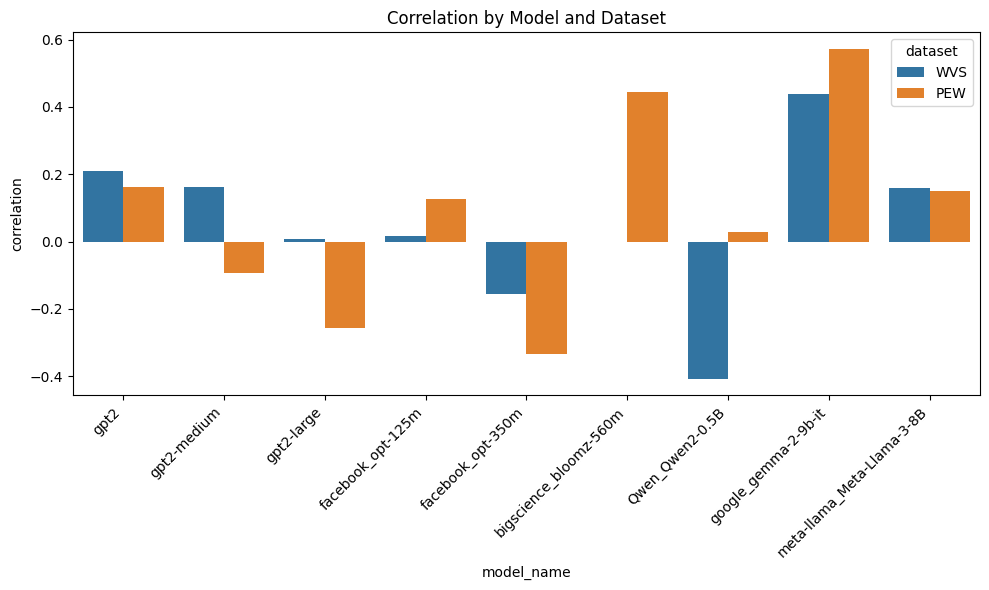

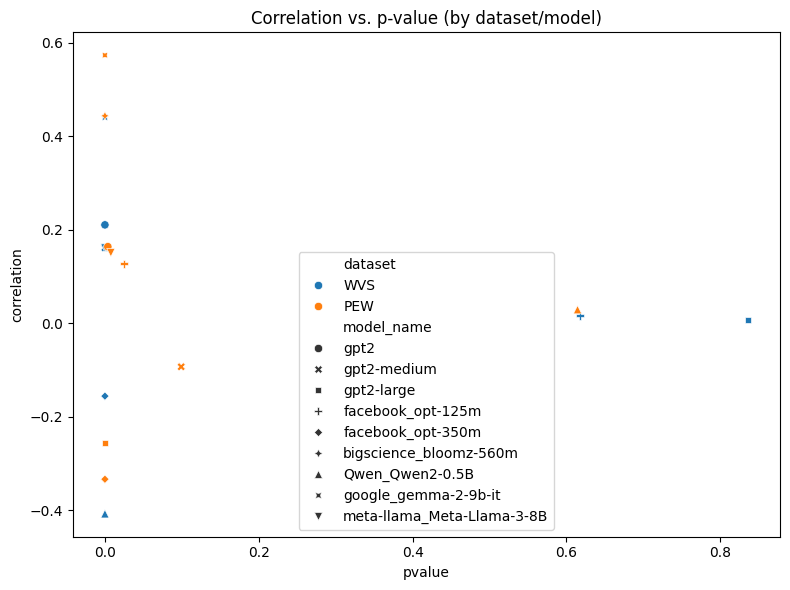


All done. Plots saved:
 - correlation_by_model_dataset.png
 - corr_vs_pval_scatter.png
Tables saved:
 - summary_correlations.csv
 - summary_correlations.tex


In [2]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
compare_model_results.py

Reads multiple CSV files (results_*.csv) generated by local_models_experiments.py,
compares correlation and p-values across models for WVS & PEW, and creates summary
plots/tables for your paper.
"""

import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def collect_results(folder="."):
    """
    Scans the given folder for CSV files named 'results_*_{WVS|PEW}.csv',
    loads them into a single DataFrame with columns:
      - model_name
      - dataset (WVS or PEW)
      - correlation (corr_overall)
      - pvalue (pvalue)
      - plus all other columns from each CSV

    Returns the combined DataFrame.
    """
    # We'll look for files matching results_*.csv
    pattern = os.path.join(folder, "results_*.csv")
    csv_files = glob.glob(pattern)

    all_rows = []
    for csv_path in csv_files:
        # Example filename: results_gpt2_WVS.csv
        # We want to parse out "gpt2" and "WVS" from that name
        basename = os.path.basename(csv_path)  # e.g. results_gpt2_WVS.csv
        # We'll try a regex approach to parse:
        #  results_  (model name)  _ (WVS or PEW).csv
        # but note that the model name might contain underscores, e.g. "meta-llama_Meta-Llama-3-8B"
        # So let's be flexible: we can detect the last underscore that precedes WVS or PEW
        match = re.match(r"results_(.*)_(WVS|PEW)\.csv", basename)
        if not match:
            print(f"Skipping file (doesn't match pattern): {basename}")
            continue

        model_str = match.group(1)
        dataset_str = match.group(2)  # "WVS" or "PEW"

        df = pd.read_csv(csv_path)
        # We'll see if these columns exist: corr_overall or correlation
        # Some scripts used 'corr_overall', others used 'correlation'
        if "corr_overall" in df.columns:
            correlation_col = "corr_overall"
        elif "correlation_overall" in df.columns:
            correlation_col = "correlation_overall"
        elif "correlation" in df.columns:
            correlation_col = "correlation"
        else:
            correlation_col = None

        if "pvalue" in df.columns:
            pval_col = "pvalue"
        elif "pvalue_overall" in df.columns:
            pval_col = "pvalue_overall"
        elif "p_value" in df.columns:
            pval_col = "p_value"
        else:
            pval_col = None

        # Extract correlation + p-value from entire DF. Typically, there's one correlation for the entire DataFrame.
        if correlation_col and correlation_col in df.columns:
            corr_value = df[correlation_col].dropna()
            # Usually the correlation is the same for every row => take first
            corr_value = corr_value.iloc[0] if len(corr_value) > 0 else None
        else:
            corr_value = None

        if pval_col and pval_col in df.columns:
            pval_value = df[pval_col].dropna()
            pval_value = pval_value.iloc[0] if len(pval_value) > 0 else None
        else:
            pval_value = None

        # We'll store a single row summarizing the entire CSV
        row = {
            "model_name": model_str,
            "dataset": dataset_str,
            "correlation": corr_value,
            "pvalue": pval_value,
            "file": basename
        }
        all_rows.append(row)

    # Combine into a single DataFrame
    results_df = pd.DataFrame(all_rows)
    return results_df


def main(folder="."):
    # 1) Collect all result files into a single DataFrame
    df_results = collect_results(folder=folder)

    if df_results.empty:
        print("No results found. Check your folder or file patterns.")
        return

    print("Combined Results:\n", df_results)

    # 2) Print a table of correlations for each model/dataset
    # Pivot so that rows = model_name, columns = dataset => correlation
    pivot_corr = df_results.pivot(index="model_name", columns="dataset", values="correlation")
    print("\nCorrelation Pivot (Model x Dataset):\n", pivot_corr)

    # 3) Let's plot a bar chart of correlation for each model/dataset
    # Melt the pivot back or just use the original df
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_results, x="model_name", y="correlation", hue="dataset")
    plt.xticks(rotation=45, ha="right")
    plt.title("Correlation by Model and Dataset")
    plt.tight_layout()
    plt.savefig("correlation_by_model_dataset.png", dpi=150)
    plt.show()

    # 4) Another plot: maybe a scatter of correlation vs p-value, separated by dataset
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_results, x="pvalue", y="correlation", hue="dataset", style="model_name")
    plt.title("Correlation vs. p-value (by dataset/model)")
    plt.tight_layout()
    plt.savefig("corr_vs_pval_scatter.png", dpi=150)
    plt.show()

    # 5) You could also build a table or latex table for the paper
    # We can export the pivot_corr to CSV or LaTeX
    pivot_corr.to_csv("summary_correlations.csv")
    with open("summary_correlations.tex", "w") as f:
        f.write(pivot_corr.to_latex(float_format="%.3f"))

    print("\nAll done. Plots saved:\n - correlation_by_model_dataset.png\n - corr_vs_pval_scatter.png")
    print("Tables saved:\n - summary_correlations.csv\n - summary_correlations.tex")


if __name__ == "__main__":
    # Change '.' to the folder where your result CSV files live, if needed.
    main(folder=".")